In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = r"../../data/processed/cleaned3.csv"
df = pd.read_csv(file_path)

# Convert TenureDays to years and handle missing/zero values
df['TenureYears'] = df['TenureDays'] / 365
df = df[df['TenureYears'].notna() & (df['TenureYears'] >= 0)]  # Filter invalid values


Define Tenure Brackets

In [2]:
# Define tenure bins and labels
bins = [0, 1, 3, 5, 10, 20]
labels = ['0–1 yrs', '1–3 yrs', '3–5 yrs', '5–10 yrs', '10+ yrs']

# Create Tenure Group column
df['TenureBracket'] = pd.cut(df['TenureYears'], bins=bins, labels=labels, right=False)

# Drop NaNs caused by values outside the bin ranges
df = df.dropna(subset=['TenureBracket'])


Employee Distribution by Tenure Bracket

C:\Users\alanm\AppData\Local\Temp\ipykernel_2236\1793211894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TenureBracket', palette='Blues_d')


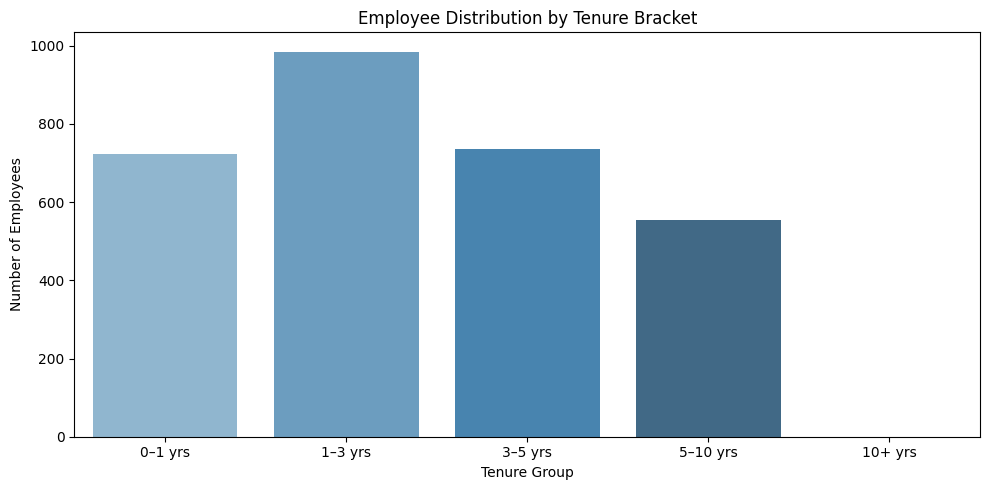

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='TenureBracket', palette='Blues_d')
plt.title("Employee Distribution by Tenure Bracket")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


Job Family by Tenure Bracket

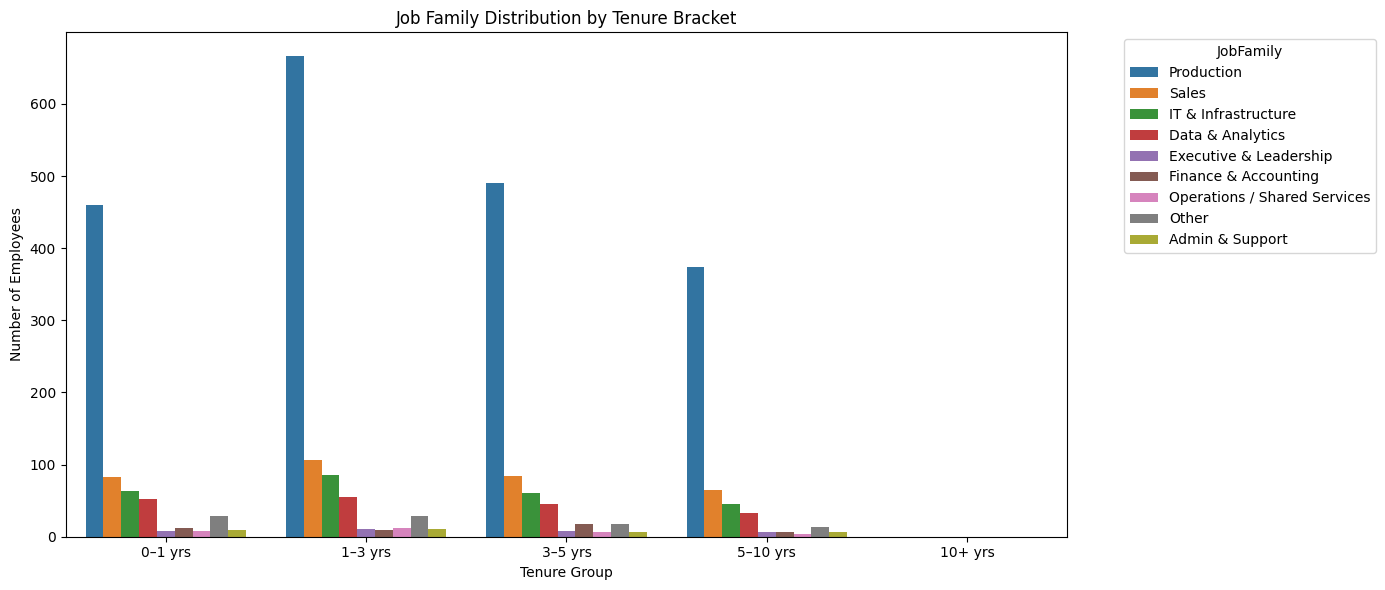

In [4]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='TenureBracket', hue='JobFamily', palette='tab10')
plt.title("Job Family Distribution by Tenure Bracket")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Employees")
plt.legend(title="JobFamily", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Seniority Level by Tenure Bracket

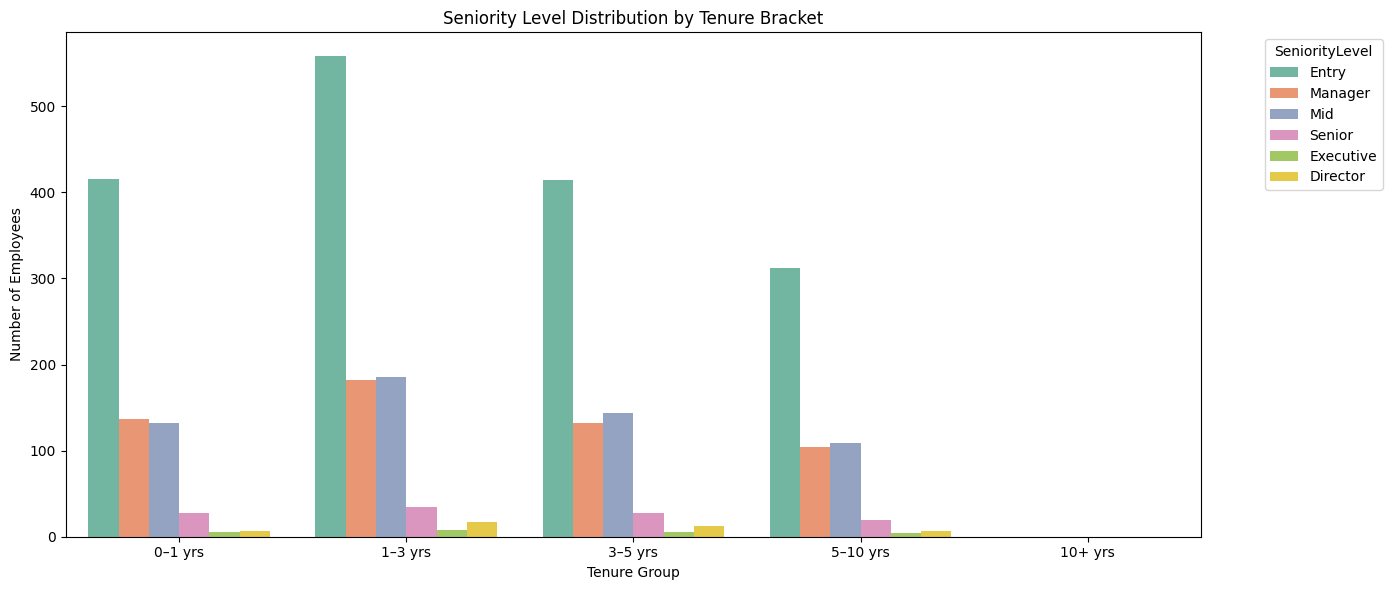

In [5]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='TenureBracket', hue='SeniorityLevel', palette='Set2')
plt.title("Seniority Level Distribution by Tenure Bracket")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Employees")
plt.legend(title="SeniorityLevel", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
